In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

cv2 (OpenCV) digunakan untuk membaca, memproses citra, dan mengonversi warna, lalu numpy untuk memanipulasi data piksel gambar dalam bentuk operasi matriks numerik, sedangkan matplotlib.pyplot berfungsi untuk menampilkan gambar dan memvisualisasikan hasil pemrosesan ke layar.

plt.imread digunakan untuk memasukkan file gambar ke dalam variabel tangan, lalu plt.imshow berfungsi untuk mengatur agar gambar tersebut siap dilihat, sedangkan plt.show digunakan untuk menampilkan gambar telapak tangan tersebut di layar.

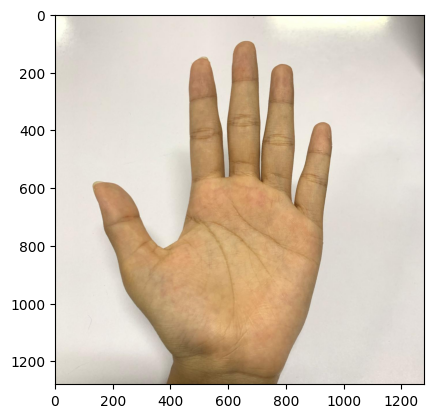

In [4]:
tangan = plt.imread('assets/telapaktangan.jpeg')
plt.imshow(tangan)
plt.show()

cv2.cvtColor digunakan untuk mengubah warna gambar di variabel tangan menjadi hitam-putih atau abu-abu, lalu plt.imshow dengan cmap='gray' mengatur agar gambar abu-abu tersebut siap dilihat, sedangkan plt.show menampilkan gambarnya di layar, dan print(tangan_gray.shape) digunakan untuk memunculkan ukuran piksel dari gambar tersebut.

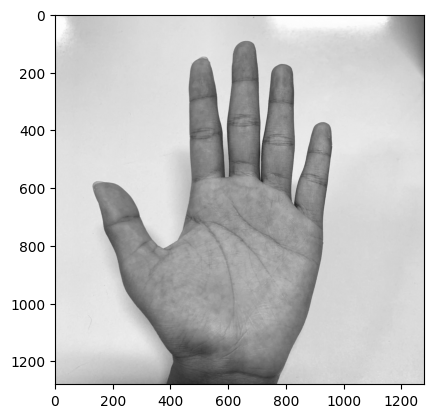

(1280, 1280)


In [5]:
tangan_gray = cv2.cvtColor(tangan, cv2.COLOR_RGB2GRAY)
plt.imshow(tangan_gray, cmap='gray')
plt.show()
print(tangan_gray.shape)

fungsi_dua dibuat untuk mengubah ukuran gambar dengan mengambil tinggi dan lebar asli lewat image.shape[:2], lalu menyediakan kanvas hitam kosong berukuran baru menggunakan np.zeros. Di dalamnya terdapat perulangan untuk menghitung posisi piksel lama menggunakan rumus x dan y agar bisa dimasukkan ke kanvas baru, kemudian fungsi ini dipanggil untuk mengubah ukuran gambar menjadi 256x256 piksel, yang akhirnya ditampilkan ke layar dan diperiksa ukuran barunya menggunakan print.

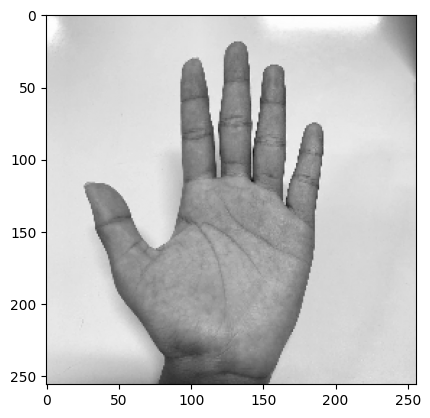

(256, 256)


In [6]:
def fungsi_dua(image, new_width, new_height): 
    old_height, old_width = image.shape[:2] 
    resized_image = np.zeros((new_height, new_width), 
dtype=np.uint8) 
    for i in range(new_height): 
        for j in range(new_width): 
            x = int(j * old_width / new_width) 
            y = int(i * old_height / new_height) 
            resized_image[i, j] = image[y, x] 
    return resized_image 

resize_tangan = fungsi_dua(tangan_gray, 256, 256)
plt.imshow(resize_tangan, cmap='gray')
plt.show()
print(resize_tangan.shape)


fungsi convolution dibuat untuk menyaring gambar dengan mengambil ukuran filter lewat kernel.shape[0], memberi bingkai tambahan pada pinggiran gambar asli menggunakan np.pad, dan menyiapkan kanvas kosong baru memakai np.zeros_like. Di dalamnya terdapat perulangan untuk mengambil area gambar sebesar ukuran filter (region) lalu mengalikan dan menjumlahkannya dengan filter lewat np.sum. Setelah itu, ditentukan dua buah filter pengubah gambar yaitu kernelSmoothing dan kernelSharpening, kemudian fungsi tersebut dipanggil menggunakan kernelSharpening untuk mempertajam gambar telapak tangan, yang akhirnya ditampilkan ke layar.

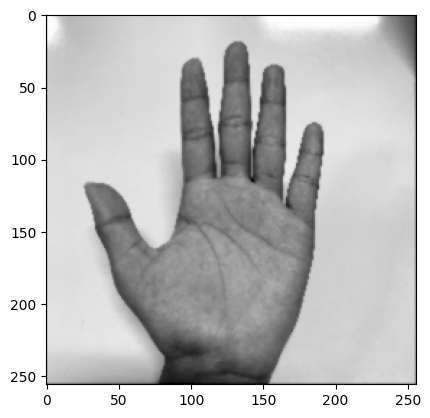

In [7]:
def convolution(img, kernel):
    size = kernel.shape[0]
    pad_size = size // 2
    padded = np.pad(img, pad_size, mode='constant')
    canvas = np.zeros_like(img).astype(np.float32)
    height, width = img.shape
    
    for i in range(height):
        for j in range(width):
            region = padded[i:i+size, j:j+size]
            canvas[i, j] = np.sum(region * kernel)
    return canvas

kernelSmoothing = np.array([
    [1/10, 1/10, 1/10],
    [1/10, 1/5,  1/10],
    [1/10, 1/10, 1/10]
 ])

kernelSharpening = np.array([
    [1/9, 1/9, 1/9],
    [1/9, 8/9, 1/9],
    [1/9, 1/9, 1/9]
])

sharp_tangan = convolution (resize_tangan, kernelSharpening)
plt.imshow(sharp_tangan, cmap='gray')
plt.show()

fungsi edge dibuat untuk mendeteksi tepi gambar dengan menghitung perubahan warna arah horizontal (gx) dan vertikal (gy) lewat fungsi konvolusi, lalu menggabungkan hasilnya menggunakan nilai mutlak np.abs. Hasil gabungan tersebut disesuaikan skalanya agar merata menggunakan rumus nilai maksimum np.max dan dibatasi nilainya antara 0 sampai 255 menggunakan np.clip. Setelah itu, ditentukan matriks pendeteksi tepi untuk metode Sobel, Prewitt, dan Roberts, kemudian fungsi tersebut dipanggil menggunakan matriks prewittX dan prewittY untuk memproses gambar telapak tangan, yang ditampilkan ke layar.

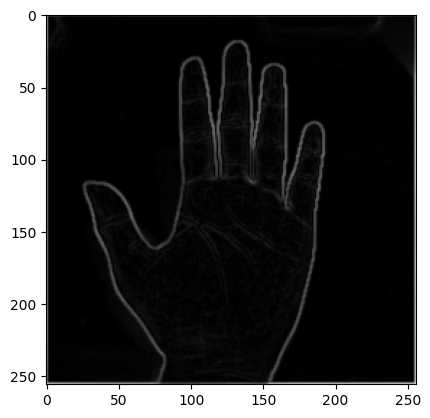

In [8]:
def edge(img, kernelx, kernely):
    gx = convolution(img, kernelx)
    gy = convolution(img, kernely)
    canvas = np.abs(gx) + np.abs(gy)
    canvas = canvas * 255.0 / np.max(canvas)
    return np.clip(canvas, 0, 255).astype(np.uint8)

sobelX = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

sobelY = np.array([
    [ 1,  2,  1],
    [ 0,  0,  0],
    [-1, -2, -1]
], dtype=np.float32)

prewittX = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
], dtype=np.float32)

prewittY = np.array([
    [ 1,  1,  1],
    [ 0,  0,  0],
    [-1, -1, -1]
], dtype=np.float32)


robertsX = np.array([
    [1,  0],
    [0, -1]
], dtype=np.float32)


robertsY = np.array([
    [ 0, 1],
    [-1, 0]
], dtype=np.float32)

prewitt_tangan = edge(sharp_tangan, prewittX, prewittY)
plt.imshow(prewitt_tangan, cmap='gray')
plt.show()

fungsi_satu dibuat untuk memisahkan objek dengan mengambil ukuran baris dan kolom gambar lewat img.shape, lalu menyiapkan kanvas kosong menggunakan np.zeros_like. Di dalamnya terdapat perulangan dan kondisi di mana jika nilai piksel gambar lebih besar dari nilai batas maka piksel di kanvas diubah menjadi putih (255), sedangkan jika kurang dari atau sama dengan nilai batas maka diubah menjadi hitam (0). Kemudian fungsi ini dipanggil dengan nilai batas 12 untuk memproses gambar telapak tangan, yang ditampilkan ke layar.

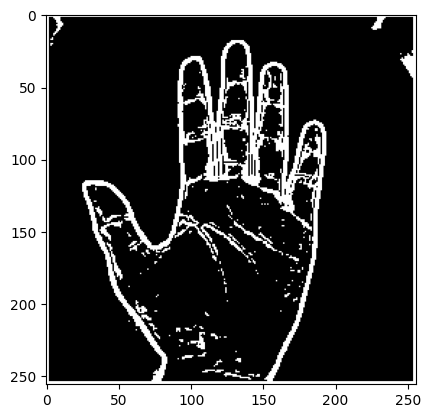

In [9]:
def fungsi_satu(img, batas): 
    baris, kolom = img.shape 
    canvas = np.zeros_like(img, dtype=np.uint8) 
    for i in range(baris): 
        for j in range(kolom): 
            if(img[i,j] > batas): 
                canvas[i,j] = 255 
            elif(img[i,j] <= batas): 
                canvas[i,j] = 0 
    return canvas 

thresholding_tangan = fungsi_satu(prewitt_tangan, 12)
plt.imshow(thresholding_tangan, cmap='gray')
plt.show()

plt.figure(figsize=(15,5)) digunakan untuk mengatur ukuran bidang tempat menggambar agar memanjang ke samping, lalu plt.subplot(1,4,...) digunakan untuk membagi bidang tersebut menjadi empat kolom berdampingan untuk diisi judul lewat plt.title dan gambar masing-masing lewat plt.imshow. Setiap bagiannya berturut-turut menyiapkan gambar asli, gambar hasil perubahan ukuran, gambar hasil deteksi tepi, dan gambar hasil pemisahan objek, yang kemudian semuanya dimunculkan secara bersamaan di layar menggunakan plt.show.

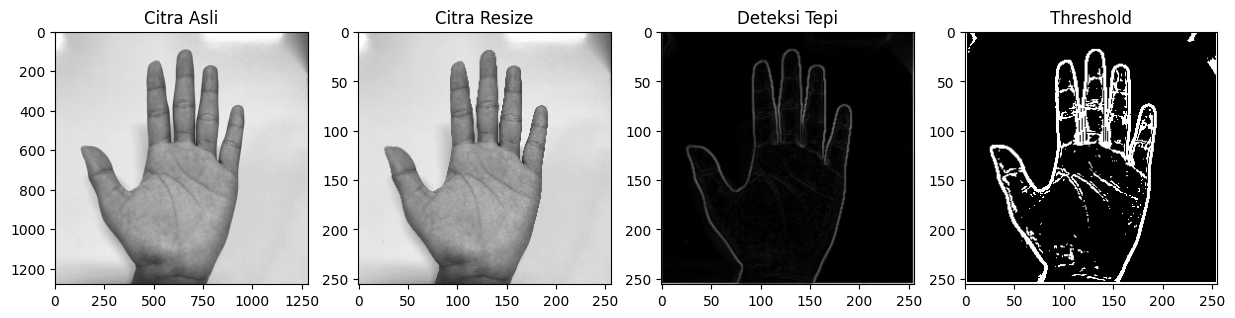

In [10]:
plt.figure(figsize=(15,5))

plt.subplot(1,4,1)
plt.title("Citra Asli")
plt.imshow(tangan_gray, cmap='gray')

plt.subplot(1,4,2)
plt.title("Citra Resize")
plt.imshow(resize_tangan, cmap='gray')

plt.subplot(1,4,3)
plt.title("Deteksi Tepi")
plt.imshow(prewitt_tangan, cmap='gray')

plt.subplot(1,4,4)
plt.title("Threshold")
plt.imshow(thresholding_tangan, cmap='gray')

plt.show()

In [11]:
kernel_diamond = np.array([ 
    [1,1,1,1,1], 
    [1,1,1,1,1], 
    [1,1,1,1,1], 
    [1,1,1,1,1], 
    [1,1,1,1,1] 
]) 
 
kernel_cross = np.array([ 
    [1,1,1], 
    [1,1,1], 
    [1,1,1] 
]) 
 
kernel_x = np.array([ 
    [1,0,0,0,1], 
    [0,1,0,1,0], 
    [0,0,1,0,0], 
    [0,1,0,1,0], 
    [1,0,0,0,1] 
], dtype=np.uint8) 

kernel_diamond, kernel_cross, dan kernel_x dibuat menggunakan np.array untuk menentukan tiga bentuk matriks atau pola penyaring biner yang berbeda. Matriks pertama berukuran 5x5 piksel diisi penuh dengan angka satu, matriks kedua berukuran 3x3 piksel juga diisi penuh dengan angka satu, sedangkan matriks ketiga berukuran 5x5 piksel diatur secara khusus membentuk pola silang huruf X dengan tipe data integer positif lewat dtype=np.uint8.

metode_satu dibuat untuk mempertebal objek gambar (dilasi) dengan mengambil ukuran tinggi dan lebar gambar lewat image.shape serta ukuran filter lewat kernel.shape, lalu menentukan titik tengah filter menggunakan pembagian k_height//2 dan menyiapkan kanvas kosong menggunakan np.zeros. Di dalamnya terdapat perulangan di mana jika piksel gambar berwarna putih (255), maka seluruh area kanvas di sekitarnya yang terkena angka satu pada filter akan ikut diubah menjadi putih (255), sedangkan piksel sisanya tetap dibiarkan berwarna hitam (0). Kemudian fungsi ini dipanggil menggunakan gambar hasil pemisahan objek dan filter bentuk kernel_cross (3x3), yang ditampilkan ke layar.

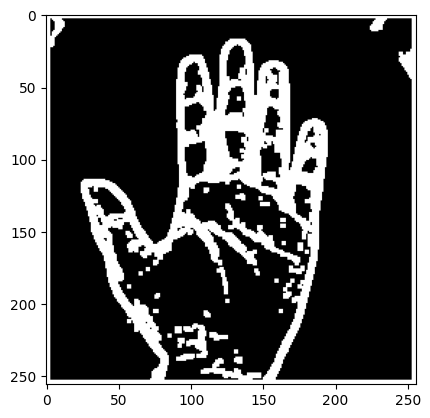

In [12]:
def metode_satu(image, kernel): 
    height, width = image.shape 
    k_height, k_width = kernel.shape 
    center = k_height//2 
    hasil = np.zeros((height, width)) 
    for i in range(center, height-center): 
        for j in range(center, width-center): 
            if image[i,j] == 255: 
                for k in range(k_height): 
                    for l in range(k_width): 
                        if kernel[k,l] == 1: 
                            hasil[i+k-center,j+l-center] =255 
            else: 
                if hasil[i,j] !=255: 
                    hasil[i,j] = 0  
    return hasil 

dilasi = metode_satu(thresholding_tangan, kernel_cross)
plt.imshow(dilasi, cmap='gray')
plt.show()

metode_dua dibuat untuk menipiskan objek gambar (erosi) dengan mengambil ukuran filter lewat kernel.shape, menentukan titik tengah filter menggunakan pembagian k_height // 2, dan menyiapkan kanvas kosong menggunakan np.zeros_like. Di dalamnya terdapat perulangan untuk memeriksa kesesuaian piksel di mana jika seluruh area gambar yang tertutup angka satu pada filter bernilai putih, maka piksel di kanvas diubah menjadi putih (255), namun jika ada satu saja piksel hitam (0) yang terkena filter maka proses dihentikan lewat break dan piksel di kanvas tetap hitam. Kemudian fungsi ini dipanggil menggunakan gambar hasil pemisahan objek dan filter bentuk kernel_cross (3x3), yang ditampilkan ke layar.

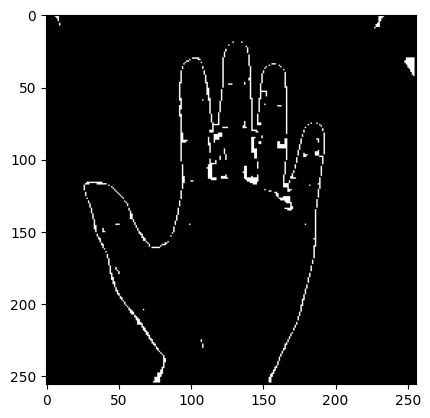

In [ ]:
def metode_dua(image, kernel):
    k_height, k_width = kernel.shape
    center = k_height // 2
    hasil = np.zeros_like(image)
    for i in range(center, image.shape[0] - center):
        for j in range(center, image.shape[1] - center):
            cocok = True
            for k in range(k_height):
                for l in range(k_width):
                    if kernel[k, l] == 1 and image[i + k - center, j + l - center] == 0:
                        cocok = False
                        break
                if not cocok:
                    break
            if cocok:
                hasil[i, j] = 255
    return hasil

erosi = metode_dua(thresholding_tangan, kernel_cross)
plt.imshow(erosi, cmap='gray')
plt.show()

In [24]:
def opening(img, kernel):
    return metode_satu(metode_dua(img,kernel),kernel)

def closing(img,kernel):
    return metode_dua(metode_satu(img,kernel),kernel)

fungsi opening dibuat untuk membersihkan bercak hitam atau menghaluskan objek dengan cara menjalankan proses penipisan gambar (metode_dua) terlebih dahulu lalu dilanjutkan dengan proses penebalan gambar (metode_satu), sedangkan fungsi closing dibuat untuk menutup lubang kecil pada objek dengan cara menjalankan proses penebalan gambar (metode_satu) terlebih dahulu baru kemudian disusul dengan proses penipisan gambar (metode_dua).

opening1 = opening(...) digunakan untuk membersihkan bercak-bercak kecil yang mengganggu pada gambar telapak tangan menggunakan filter bentuk kernel_cross (3x3).

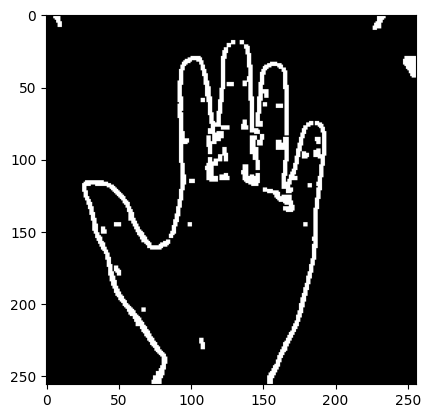

In [25]:
opening1 = opening(thresholding_tangan, kernel_cross)
plt.imshow(opening1, cmap='gray')
plt.show()

closing1 = closing(...) digunakan untuk menutup lubang-lubang kecil yang terputus pada gambar telapak tangan menggunakan filter bentuk kernel_cross (3x3).

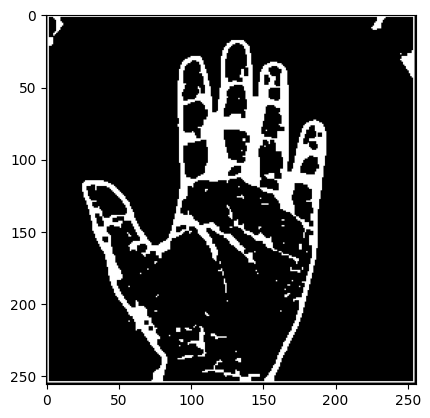

In [26]:
closing1 = closing(thresholding_tangan, kernel_cross)
plt.imshow(closing1, cmap='gray')
plt.show()

def Thinning dibuat untuk menipiskan objek gambar hingga menyisakan kerangka intinya saja dengan mengubah gambar menjadi biner (0 dan 1) lewat img > 0, lalu melakukan perulangan while terus-menerus selama masih ada piksel yang bisa dihapus. Di dalam perulangan tersebut, posisi delapan piksel tetangga (P2 sampai P9) diperiksa untuk dihitung jumlah piksel putihnya menggunakan np.sum serta dihitung pola perubahan warnanya lewat variabel transisi. Proses pengecekan ini dibagi menjadi dua tahap seleksi kondisi khusus untuk menentukan piksel pinggir mana saja yang boleh dihapus tanpa memutuskan bentuk objek, yang kemudian koordinatnya ditampung di dalam daftar hapus untuk diubah menjadi hitam (0). Terakhir, setelah tidak ada lagi piksel yang memenuhi syarat untuk dihapus, gambar kerangka tersebut dikembalikan ke skala semula dengan dikalikan 255, lalu fungsi dipanggil menggunakan gambar hasil pemisahan objek dan hasilnya ditampilkan ke layar.

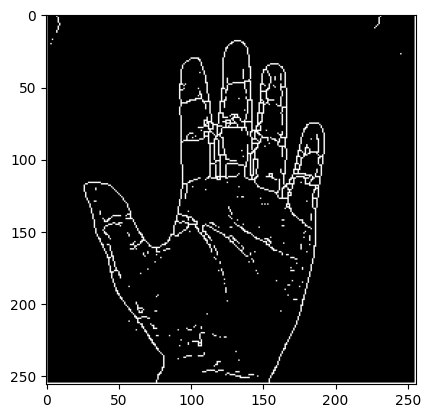

In [16]:
def Thinning(img): 
    binary = (img > 0).astype(np.uint8) 
    height, width = binary.shape 
    changed = True 
    while changed: 
        changed = False 
        hapus = [] 
        for i in range(1, height-1): 
            for j in range(1, width-1): 
                P1 = binary[i, j] 
                if P1 != 1: 
                    continue 
                P2 = binary[i-1, j] 
                P3 = binary[i-1, j+1] 
                P4 = binary[i, j+1] 
                P5 = binary[i+1, j+1] 
                P6 = binary[i+1, j] 
                P7 = binary[i+1, j-1] 
                P8 = binary[i, j-1] 
                P9 = binary[i-1, j-1] 
                tetangga = [P2,P3,P4,P5,P6,P7,P8,P9] 
                jumlah = np.sum(tetangga) 
                transisi = 0 
                urutan = tetangga + [P2] 
                for k in range(8): 
                    if urutan[k] == 0 and urutan[k+1] == 1: 
                        transisi += 1 
                if ( 
                    2 <= jumlah <= 6 and 
                    transisi == 1 and 
                    P2 * P4 * P6 == 0 and 
                    P4 * P6 * P8 == 0 
                ): 
                    hapus.append((i,j)) 
        if hapus: 
            changed = True 
            for i,j in hapus: 
                binary[i,j] = 0 
        hapus = [] 
        for i in range(1, height-1): 
            for j in range(1, width-1): 
 
                P1 = binary[i, j] 
                if P1 != 1: 
                    continue 
                P2 = binary[i-1, j] 
                P3 = binary[i-1, j+1] 
                P4 = binary[i, j+1] 
                P5 = binary[i+1, j+1] 
                P6 = binary[i+1, j] 
                P7 = binary[i+1, j-1] 
                P8 = binary[i, j-1] 
                P9 = binary[i-1, j-1] 
                tetangga = [P2,P3,P4,P5,P6,P7,P8,P9] 
                jumlah = np.sum(tetangga) 
                transisi = 0 
                urutan = tetangga + [P2] 
                for k in range(8): 
                    if urutan[k] == 0 and urutan[k+1] == 1: 
                        transisi += 1 
 
                if ( 
                    2 <= jumlah <= 6 and 
                    transisi == 1 and 
                    P2 * P4 * P8 == 0 and 
                    P2 * P6 * P8 == 0 
                ): 
                    hapus.append((i,j)) 
        if hapus: 
            changed = True 
            for i,j in hapus: 
                binary[i,j] = 0 
    return binary * 255 

thinning = Thinning (thresholding_tangan)
plt.imshow(thinning, cmap='gray')
plt.show()

def Thickening dibuat untuk mempertebal ukuran objek gambar sebanyak yang diinginkan dengan membuat salinan gambar asli lewat img.copy(), lalu melakukan perulangan for sebanyak nilai variabel iterasi. Di dalam perulangan tersebut, fungsi penebalan gambar (metode_satu) dipanggil secara berulang menggunakan filter yang ditentukan untuk memperluas area piksel putih. Kemudian fungsi ini dipanggil dengan memasukkan gambar hasil pemisahan objek, filter bentuk kernel_cross (3x3), serta jumlah perulangan sebanyak satu kali, yang akhirnya hasil penebalan tersebut ditampilkan ke layar.

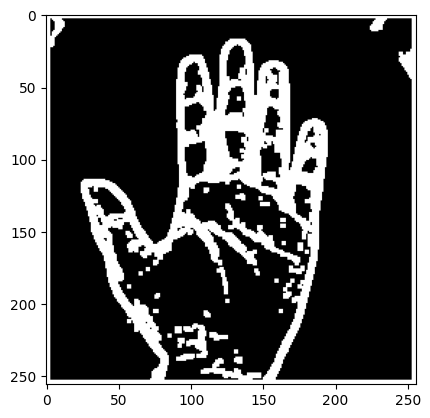

In [17]:
def Thickening(img, kernel, iterasi=1): 
    hasil = img.copy() 
    for _ in range(iterasi): 
        hasil = metode_satu(hasil, kernel) 
    return hasil 

thickening = Thickening (thresholding_tangan, kernel_cross, iterasi=1)
plt.imshow(thickening, cmap='gray')
plt.show()

gradient_morph = dilasi - erosi digunakan untuk melakukan operasi Morphological Gradient (Gradien Morfologi), yaitu mencari garis tepi atau kontur objek dengan cara mengurangi gambar hasil penebalan (dilasi) dengan gambar hasil penipisan (erosi). Selisih dari kedua proses tersebut akan menghasilkan garis luar yang presisi karena area tepi yang tebal dikurangi area dalam yang tipis.

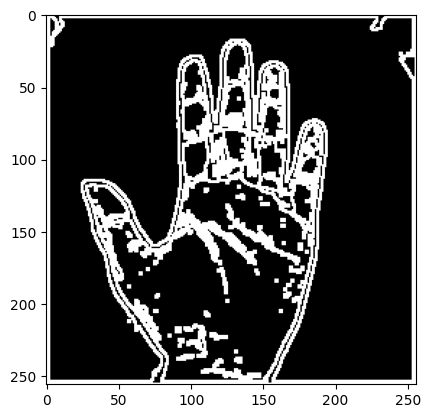

In [18]:
gradient_morph = dilasi- erosi
plt.imshow(gradient_morph, cmap='gray')
plt.show()

plt.figure(figsize=(15,8)) digunakan untuk mengatur ukuran lembar gambar menjadi lebih luas (lebar 15 dan tinggi 8 inci), lalu plt.subplot(2,4,...) membagi lembar tersebut secara teratur menjadi matriks tampilan dua baris dan empat kolom. Di setiap bagiannya, plt.title memberikan nama label di atas gambar, plt.imshow dengan warna abu-abu (cmap='gray'), dan plt.axis('off') digunakan untuk menghilangkan garis skala beserta angka koordinat pada pinggiran gambar agar tampilannya terlihat lebih bersih dan rapi.

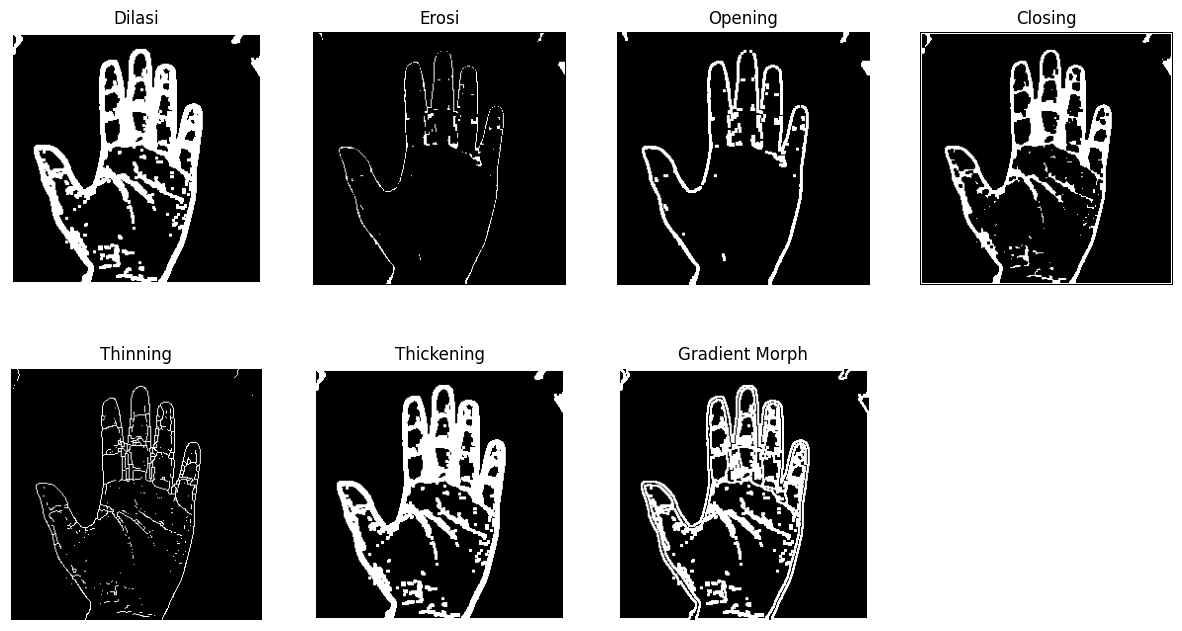

In [27]:
plt.figure(figsize=(15,8))

plt.subplot(2,4,1)
plt.title("Dilasi")
plt.imshow(dilasi, cmap='gray')
plt.axis('off')

plt.subplot(2,4,2)
plt.title("Erosi")
plt.imshow(erosi, cmap='gray')
plt.axis('off')

plt.subplot(2,4,3)
plt.title("Opening")
plt.imshow(opening1, cmap='gray')
plt.axis('off')

plt.subplot(2,4,4)
plt.title("Closing")
plt.imshow(closing1, cmap='gray')
plt.axis('off')

plt.subplot(2,4,5)
plt.title("Thinning")
plt.imshow(thinning, cmap='gray')
plt.axis('off')

plt.subplot(2,4,6)
plt.title("Thickening")
plt.imshow(thickening, cmap='gray')
plt.axis('off')

plt.subplot(2,4,7)
plt.title("Gradient Morph")
plt.imshow(gradient_morph, cmap='gray')
plt.axis('off')

plt.show()

ANALISIS

Operasi morfologi dijalankan menggunakan kernel_cross yang merupakan matriks 3×3 dengan semua elemen bernilai 1. Citra input yang digunakan adalah thresholding_tangan, yaitu hasil binerisasi citra telapak tangan di mana piksel bernilai putih (255) merepresentasikan tepi objek dan piksel bernilai hitam (0) merepresentasikan latar belakang. Hasil dari setiap operasi morfologi menunjukkan perbedaan yang jelas terhadap citra asli. Pada Dilasi (metode_satu), area piksel putih melebar ke segala arah sehingga garis tepi tangan tampak lebih tebal dan celah kecil yang terputus menjadi tersambung. Pada Erosi (metode_dua), piksel putih hanya dipertahankan jika seluruh tetangganya juga putih sehingga garis tepi menyusut dan titik derau kecil yang terisolasi menghilang. Pada Opening (erosi lalu dilasi), bercak-bercak putih kecil di luar objek utama terhapus sehingga citra lebih bersih namun bentuk objek sedikit mengecil. Pada Closing (dilasi lalu erosi), lubang-lubang kecil di dalam area objek tertutup sehingga kontur tangan terlihat lebih solid. Pada Thinning, garis tepi tangan diperkecil hingga membentuk kerangka satu piksel yang merepresentasikan struktur inti objek. Pada Thickening, objek dipertebal satu lapisan piksel ke segala arah menggunakan dilasi satu iterasi. Pada Morphological Gradient (dilasi dikurangi erosi), hasil selisih kedua operasi tersebut menghasilkan garis kontur luar objek yang presisi karena hanya area pinggiran yang tersisa. Secara keseluruhan, perbedaan utama antara citra hasil morfologi dan citra asli terletak pada ketebalan, kelengkapan, dan kebersihan garis tepi objek, di mana kernel 3×3 penuh memberikan pengaruh yang merata ke seluruh arah tetangga sehingga setiap operasi menghasilkan perubahan yang simetris dan konsisten pada struktur citra biner.

Serangkaian operasi morfologi pada gambar hasil pemisahan objek (thresholding_tangan), tetapi kali ini beralih menggunakan penyaring berbentuk kotak berukuran 5x5 piksel penuh (kernel_diamond). Prosesnya dimulai dengan menghitung hasil Dilasi, Erosi, Opening, dan Closing yang baru, lalu mempertebal objek lewat fungsi Thickening, serta mencari garis tepi luar objek (gradient_morph2) dengan mengurangkan hasil dilasi kedua dan erosi kedua.

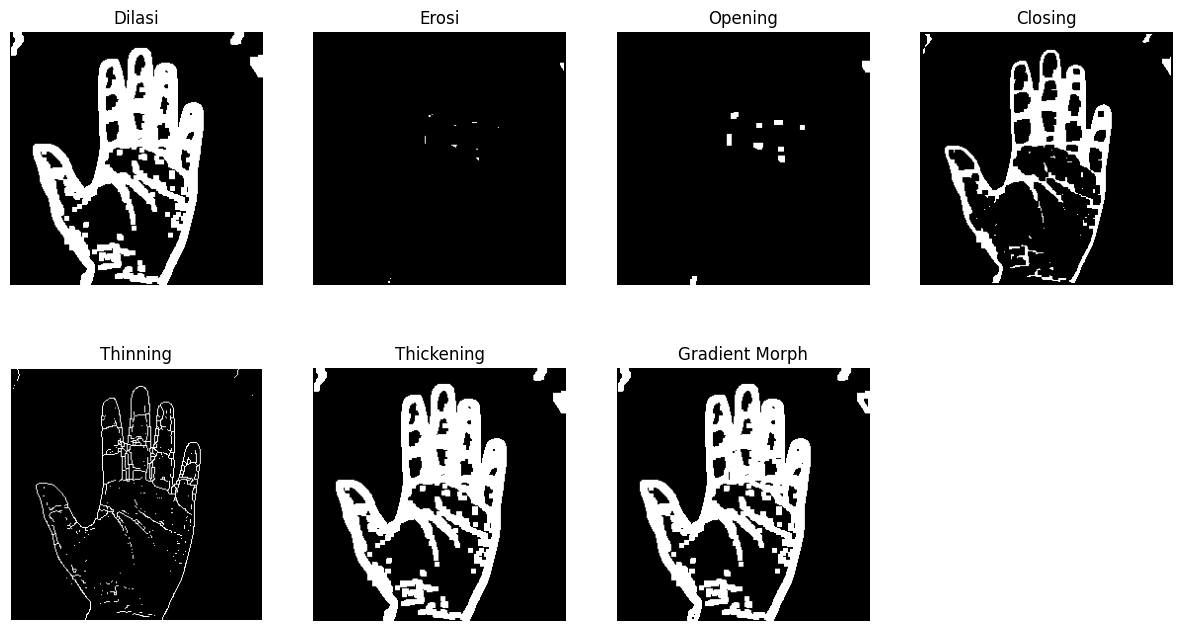

In [31]:
dilasi2 = metode_satu(thresholding_tangan, kernel_diamond)
erosi2 = metode_dua(thresholding_tangan, kernel_diamond)
opening2 = opening(thresholding_tangan, kernel_diamond)
closing2 = closing(thresholding_tangan, kernel_diamond)
thickening2 = Thickening (thresholding_tangan, kernel_diamond, iterasi=1)
gradient_morph2 = dilasi2- erosi2

plt.figure(figsize=(15,8))

plt.subplot(2,4,1)
plt.title("Dilasi")
plt.imshow(dilasi2, cmap='gray')
plt.axis('off')

plt.subplot(2,4,2)
plt.title("Erosi")
plt.imshow(erosi2, cmap='gray')
plt.axis('off')

plt.subplot(2,4,3)
plt.title("Opening")
plt.imshow(opening2, cmap='gray')
plt.axis('off')

plt.subplot(2,4,4)
plt.title("Closing")
plt.imshow(closing2, cmap='gray')
plt.axis('off')

plt.subplot(2,4,5)
plt.title("Thinning")
plt.imshow(thinning, cmap='gray')
plt.axis('off')

plt.subplot(2,4,6)
plt.title("Thickening")
plt.imshow(thickening2, cmap='gray')
plt.axis('off')

plt.subplot(2,4,7)
plt.title("Gradient Morph")
plt.imshow(gradient_morph2, cmap='gray')
plt.axis('off')

plt.show()

ANALISIS:

Operasi morfologi dengan kernel 5×5 semua elemen bernilai 1 menggunakan kernel_diamond telah dijalankan dan hasilnya disimpan pada variabel dilasi2, erosi2, opening2, closing2, thickening2, dan gradient_morph2. Dibandingkan dengan kernel 3×3, penggunaan kernel 5×5 memberikan dampak yang jauh lebih besar pada setiap operasi morfologi. Pada Dilasi, area piksel putih melebar lebih jauh ke segala arah sehingga garis tepi tangan tampak jauh lebih tebal dibanding hasil kernel 3×3 dan celah-celah yang terputus lebih mudah tersambung bahkan untuk celah yang lebih lebar sekalipun. Pada Erosi, penyusutan piksel putih terjadi lebih dalam sehingga garis tepi yang tersisa jauh lebih tipis dan titik-titik derau yang lebih besar pun ikut terhapus, sementara pada kernel 3×3 derau berukuran sedang masih bisa bertahan. Pada Opening, pembersihan bercak-bercak kecil di luar objek utama lebih tuntas karena ambang minimum luas area yang bisa bertahan lebih besar, namun konsekuensinya detail-detail kecil pada bentuk tangan juga ikut terkikis lebih signifikan. Pada Closing, lubang dan celah yang tertutup lebih banyak dan lebih lebar dibanding kernel 3×3, sehingga kontur objek terlihat lebih masif dan padat namun kehilangan detail lekukan halus. Pada Thickening, penebalan yang dihasilkan lebih drastis dalam satu iterasi saja karena jangkauan kernel yang lebih luas, membuat objek tangan tampak membengkak lebih besar. Pada Morphological Gradient, garis kontur yang dihasilkan lebih tebal dibanding kernel 3×3 karena selisih antara dilasi dan erosi yang lebih besar, sehingga garis tepi tampak lebih kasar namun lebih mudah terlihat. Secara keseluruhan, perbedaan mendasar antara kernel 5×5 dan 3×3 terletak pada skala pengaruhnya, di mana kernel 5×5 menghasilkan perubahan yang lebih ekstrem pada ketebalan objek, lebih efektif dalam menghilangkan noise berukuran lebih besar, namun juga lebih destruktif terhadap detail halus dan bentuk asli objek karena jangkauan tetangganya yang dua kali lebih luas.

Proses kombinasi yang dilakukan adalah:

oc: Melakukan Opening terlebih dahulu untuk menghapus derau luar kecil, lalu dilanjutkan dengan Closing untuk menutup lubang kecil yang tersisa di dalam objek.
co: Melakukan Closing terlebih dahulu untuk menggabungkan area atau menutup lubang di dalam objek, baru disusul dengan Opening untuk merapikan pinggiran objek dari derau luar.
od: Mengambil gambar yang sudah bersih dari hasil Opening, kemudian dipertebal ukurannya menggunakan fungsi Dilasi (metode_satu).
ce: Mengambil gambar yang lubangnya sudah tertutup dari hasil Closing, kemudian ditipiskan kembali ukuran objeknya menggunakan fungsi Erosi (metode_dua).

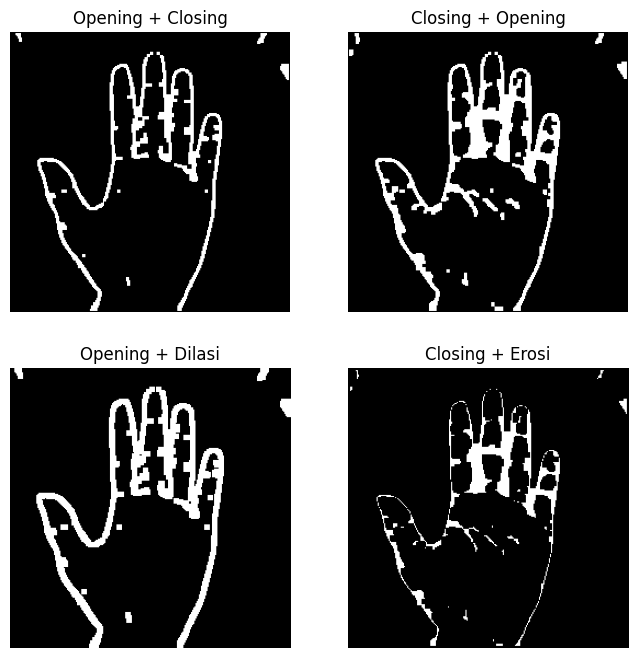

In [35]:
#kernel 3 x 3
oc = closing(opening1, kernel_cross)
co = opening(closing1, kernel_cross)
od = metode_satu(opening1, kernel_cross)
ce = metode_dua(closing1, kernel_cross)

plt.figure(figsize=(8,8))

plt.subplot(2,2,1)
plt.title("Opening + Closing")
plt.imshow(oc, cmap='gray')
plt.axis('off')

plt.subplot(2,2,2)
plt.title("Closing + Opening")
plt.imshow(co, cmap='gray')
plt.axis('off')

plt.subplot(2,2,3)
plt.title("Opening + Dilasi")
plt.imshow(od, cmap='gray')
plt.axis('off')

plt.subplot(2,2,4)
plt.title("Closing + Erosi")
plt.imshow(ce, cmap='gray')
plt.axis('off')

plt.show()

ANALISIS:

Kombinasi operasi morfologi telah dijalankan menggunakan kernel_cross (3×3) dengan empat variasi kombinasi yaitu oc (Opening, lalu Closing), co (Closing, lalu Opening), od (Opening, lalu Dilasi), dan ce (Closing, lalu Erosi), semuanya berbasis pada citra thresholding_tangan sebagai input. Dibandingkan dengan operasi morfologi tunggal maupun citra asli, setiap kombinasi memberikan karakteristik hasil yang berbeda-beda. Pada kombinasi Opening ke Closing (oc), bercak derau kecil di luar objek terlebih dahulu dihapus oleh Opening, lalu lubang-lubang kecil yang tersisa di dalam objek ditutup oleh Closing, sehingga hasil akhirnya adalah citra yang paling bersih dan paling rapi dibanding operasi tunggal manapun karena kedua jenis gangguan ditangani sekaligus dalam satu alur. Pada kombinasi Closing→ ke Opening (co), lubang dalam objek ditutup terlebih dahulu oleh Closing, kemudian bercak luar dihapus oleh Opening, menghasilkan bentuk objek yang solid namun dengan pinggiran yang sedikit lebih terkikis dibanding oc karena erosi pada tahap Opening diaplikasikan setelah objek sudah mengembang akibat Closing sebelumnya. Pada kombinasi Opening ke Dilasi (od), citra yang sudah dibersihkan dari derau oleh Opening kemudian dipertebal kembali oleh Dilasi, sehingga ketebalan garis tepi mendekati atau bahkan melebihi citra asli namun dengan kondisi yang lebih bersih karena derau kecil tidak ikut menebal seperti halnya jika Dilasi langsung diterapkan tanpa Opening. Pada kombinasi Closing ke Erosi (ce), objek yang lubangnya sudah tertutup oleh Closing kemudian ditipiskan kembali oleh Erosi, menghasilkan garis tepi yang lebih tipis namun lebih solid dan minim celah dibanding erosi tunggal yang langsung diterapkan pada citra asli. Secara keseluruhan, kombinasi dua operasi morfologi secara berurutan terbukti lebih unggul dibanding operasi tunggal karena mampu menangani dua masalah sekaligus yaitu pengurangan noise eksternal dan perbaikan integritas internal objek, dengan trade-off bahwa setiap tambahan operasi berisiko mengikis atau mengubah detail halus bentuk objek lebih jauh dari citra aslinya.

In [36]:
def filter(img, size, mode):
    height, width = img.shape
    pad = size // 2
    padded = np.pad(img, pad, mode='edge')
    canvas = np.zeros_like(img, dtype=np.uint8)
    match mode:
        case 'mean':
            area = size * size
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    total = 0
                    for val in region.ravel():
                        total += int(val)
                    canvas[i, j] = total // area
        case 'median':
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    values = sorted(region.ravel())
                    mid = len(values) // 2
                    canvas[i, j] = values[mid]
        case 'modus':
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    values = region.ravel()
                    count = {}
                    for val in values:
                        count[val] = count.get(val, 0) + 1
                    mode_val = max(count, key=count.get)
                    canvas[i, j] = mode_val
    return canvas

Fungsi filter dibuat untuk mereduksi derau pada citra menggunakan teknik spatial filtering berbasis pemrosesan tetangga (neighborhood processing), di mana pinggiran gambar diperluas terlebih dahulu dengan padding bertipe edge agar ukuran piksel tepi tetap terjaga saat diproses oleh filter. Di dalam fungsi ini, terdapat struktur match mode untuk memilih tiga jenis operasi penyaringan: mode mean untuk menghaluskan citra dengan menghitung nilai rata-rata seluruh piksel di dalam jendela, mode median untuk mereduksi derau saltpepper dengan mengambil nilai tengah dari sekumpulan piksel yang telah diurutkan, serta mode modus untuk mempertahankan dominasi warna dengan mencari nilai piksel yang paling sering muncul menggunakan frekuensi. Setelah seluruh koordinat baris dan kolom selesai dipindai dan dimanipulasi sesuai mode terpilih, fungsi akan mengembalikan matriks citra baru berupa canvas bertipe data np.uint8.

Melakukan serangkaian proses pengolahan citra digital untuk mengekstrak dan mempertegas garis tepi (outline) objek tangan, yang kemudian divisualisasikan dalam bentuk kisi plot 2x3 menggunakan Matplotlib. Alur prosesnya diawali dengan mengubah ukuran gambar asli menjadi 520x520 piksel melalui fungsi_dua, lalu mereduksi derau halus menggunakan filter median berukuran 3x3 piksel agar proses deteksi tepi lebih bersih. Selanjutnya, operator prewitt digunakan untuk mendeteksi struktur garis tepi, diikuti dengan proses binerisasi lewat fungsi_satu dengan ambang batas (threshold) sebesar 12 untuk memisahkan objek tepi dari latar belakangnya. Untuk memperkuat kontur, dilakukan operasi Thickening sebanyak satu kali iterasi menggunakan kernel_cross (3x3), dan sebagai langkah akhir, deteksi tepi prewitt diaplikasikan kembali pada hasil penebalan tersebut untuk mendapatkan garis luar yang lebih tegas.

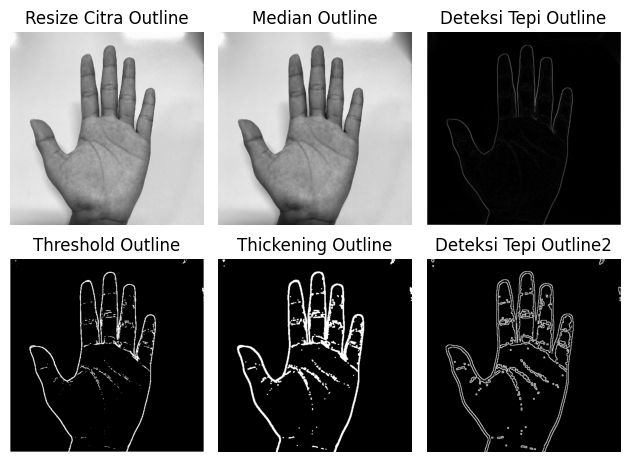

In [40]:
resize_outline = fungsi_dua(tangan_gray, 520, 520)
outline_median = filter(resize_outline, 3, 'median')
outline_prewitt = edge(outline_median, prewittX, prewittY)
outline_thres = fungsi_satu(outline_prewitt, 12)
outline_thickening = Thickening(outline_thres, kernel_cross, iterasi=1)
outline_prewitt2 = edge(outline_thickening, prewittX, prewittY)

plt.subplot(2,3,1)
plt.title("Resize Citra Outline")
plt.imshow(resize_outline, cmap='gray')
plt.axis('off')

plt.subplot(2,3,2)
plt.title("Median Outline")
plt.imshow(outline_median, cmap='gray')  
plt.axis('off') 

plt.subplot(2,3,3)
plt.title("Deteksi Tepi Outline")
plt.imshow(outline_prewitt, cmap='gray')
plt.axis('off')

plt.subplot(2,3,4)
plt.title("Threshold Outline")
plt.imshow(outline_thres, cmap='gray')
plt.axis('off')

plt.subplot(2,3,5)
plt.title("Thickening Outline")
plt.imshow(outline_thickening, cmap='gray')
plt.axis('off')

plt.subplot(2,3,6)
plt.title("Deteksi Tepi Outline2")
plt.imshow(outline_prewitt2, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

ANALISIS:

Pengolahan citra untuk menghasilkan outline telapak tangan dibangun melalui enam tahapan berurutan yang tersimpan mulai dari resize_outline hingga outline_prewitt2. Tahap pertama adalah Resize 520×520 menggunakan fungsi_dua, dipilih karena ukuran yang lebih besar dibanding resize sebelumnya (256×256) memberikan resolusi yang lebih tinggi sehingga detail lekukan jari dan tepi tangan dapat dipertahankan lebih baik saat proses deteksi tepi berlangsung. Tahap kedua adalah Median Filter 3×3 menggunakan filter(resize_outline, 3, 'median'), dipilih secara spesifik karena median lebih unggul dari mean dalam menghilangkan derau saltpepper yang umum muncul pada citra telapak tangan tanpa mengaburkan tepi objek, sehingga hasil deteksi tepi pada tahap berikutnya menjadi lebih bersih dan tidak terganggu oleh piksel derau yang mencolok. Tahap ketiga adalah Deteksi Tepi Prewitt menggunakan edge(outline_median, prewittX, prewittY), dipilih karena operator Prewitt sensitif terhadap perubahan intensitas gradien pada arah horizontal dan vertikal secara bersamaan sehingga mampu menangkap kontur tepi tangan dari berbagai sudut dengan respons yang lebih merata dibanding Roberts yang hanya efektif pada tepi diagonal. Tahap keempat adalah Thresholding dengan batas 12 menggunakan fungsi_satu(outline_prewitt, 12), dipilih untuk mengubah hasil deteksi tepi yang masih berupa gradien abu-abu menjadi citra biner tegas di mana hanya tepi yang memiliki kekuatan respons di atas ambang batas yang dipertahankan sebagai putih, nilai 12 dipilih karena cukup rendah untuk menangkap tepi-tepi halus namun tetap mampu menyaring gradien lemah yang bukan merupakan tepi sejati. Tahap kelima adalah Thickening satu iterasi menggunakan Thickening(outline_thres, kernel_cross, iterasi=1), dipilih karena hasil thresholding seringkali menghasilkan garis tepi yang terlalu tipis dan terputus-putus, sehingga satu iterasi penebalan dengan kernel 3×3 cukup untuk menyambungkan celah kecil dan mempertegas kontur tanpa membuat garis menjadi terlalu tebal atau kehilangan bentuk aslinya. Tahap keenam adalah Deteksi Tepi Prewitt kedua menggunakan edge(outline_thickening, prewittX, prewittY), diterapkan kembali pada hasil thickening untuk mengekstrak sisi luar dari garis yang sudah dipertebal sehingga menghasilkan outline yang lebih presisi, tipis, dan bersih sebagai garis kontur akhir. Secara keseluruhan, kombinasi keenam tahapan ini terbukti efektif karena setiap proses dirancang untuk mengatasi kelemahan tahap sebelumnya secara berurutan, mulai dari memastikan resolusi cukup, membersihkan derau, mendeteksi tepi, mempertegas biner, menyambungkan kontur, hingga mengekstrak garis akhir yang tajam dan representatif sebagai outline telapak tangan.

KESIMPULAN:

Berdasarkan seluruh praktikum yang telah dilakukan pada Modul 4, dapat disimpulkan bahwa morfologi citra merupakan teknik pengolahan citra berbasis bentuk yang bekerja dengan cara mengoperasikan elemen struktural (kernel) terhadap piksel-piksel biner pada citra, di mana ukuran dan bentuk kernel terbukti menjadi parameter paling krusial yang menentukan skala dan sifat perubahan yang dihasilkan. Konsep morfologi berhasil dipahami secara menyeluruh melalui implementasi manual tujuh operasi utama yaitu Dilasi, Erosi, Opening, Closing, Thinning, Thickening, dan Morphological Gradient, di mana setiap operasi memiliki peran spesifik dalam memodifikasi bentuk, ukuran, dan fitur objek pada citra sesuai dengan tujuan pembelajaran pertama modul ini. Implementasi seluruh operasi tersebut dilakukan dari nol tanpa bergantung pada fungsi morfologi bawaan library, sehingga memberikan pemahaman mendalam tentang mekanisme kerja setiap algoritma di balik prosesnya. Analisis terhadap pengaruh parameter kernel menunjukkan bahwa kernel 3×3 menghasilkan perubahan yang lebih halus dan mampu mempertahankan detail objek, sementara kernel 5×5 memberikan dampak yang lebih agresif dalam menghilangkan noise maupun mengubah bentuk objek, sehingga pemilihan ukuran kernel harus disesuaikan dengan kebutuhan dan karakteristik citra yang diproses. Kombinasi operasi morfologi secara berurutan seperti Opening ke Closing dan Closing ke Opening juga terbukti lebih efektif dibanding operasi tunggal karena mampu menangani pengurangan noise eksternal dan perbaikan integritas internal objek secara bersamaan. Puncak dari seluruh proses ini tercermin pada tahap eksplorasi pipeline outline telapak tangan yang menggabungkan resize, median filter, deteksi tepi Prewitt, thresholding, thickening, hingga deteksi tepi kedua secara berurutan, membuktikan bahwa pemilihan dan pengurutan operasi morfologi yang tepat mampu menghasilkan kontur objek yang bersih, presisi, dan representatif. Dengan demikian, kedua CPMK modul ini telah tercapai, yaitu mahasiswa mampu memahami konsep morfologi untuk memodifikasi bentuk dan fitur objek dalam citra sekaligus mampu mengimplementasikan dan menganalisis pengaruh parameter terhadap hasil transformasi morfologi secara sistematis dan terukur.